In [1]:
!pip install pygame
!pip install box2d-py
!pip install Box2D
!pip install gym[box2d]

  Using cached box2d-py-2.3.8.tar.gz (374 kB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for box2d-py
  Running setup.py clean for box2d-py
Failed to build box2d-py
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (box2d-py)
  Using cached box2d-py-2.3.5.tar.gz (374 kB)
  Preparing metadata (setup.py) ... done
  Using cached pygame-2.1.0.tar.gz (5.8 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generati

In [2]:
# ══════════════════ imports & globals ══════════════════════════════════════
import gym, torch, torch.nn as nn, torch.optim as optim
import numpy as np, random, itertools, pandas as pd
from torch.distributions import Normal

import os, matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML    # only used by show_video()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- NumPy 2.0 shim for old Gym builds -------------------------------------
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

In [4]:
# ══════════════════ 1. networks ════════════════════════════════════════════
class Policy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=128):
        super().__init__()
        self.fc1  = nn.Linear(obs_dim, hidden)
        self.fc2  = nn.Linear(hidden, hidden)
        self.mean = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        return self.mean(x), torch.exp(self.log_std)


class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.v   = nn.Linear(hidden, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        return self.v(x).squeeze(-1)

In [5]:
# ══════════════════ 2. helpers ═════════════════════════════════════════════
def set_seed(seed=0):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def discount(r, γ):
    out, R = [], 0.0
    for reward in reversed(r):
        R = reward + γ * R; out.insert(0, R)
    return out

# --- Gym-API–agnostic wrappers --------------------------------------------
def env_reset(env, *, seed=None):
    """Return obs only; handles (obs) or (obs, info) across Gym versions."""
    if seed is not None:
        try:                        # new API
            out = env.reset(seed=seed)
        except TypeError:           # very old API
            env.seed(seed); out = env.reset()
    else:
        out = env.reset()
    return out[0] if isinstance(out, tuple) else out

def env_step(env, action):
    """Always return obs, reward, done."""
    if isinstance(action, np.ndarray) and action.ndim > 1:
        action = action.squeeze(0)
    out = env.step(action)
    if len(out) == 5:               # new API
        obs, r, terminated, truncated, _ = out
        done = terminated or truncated
    else:                           # old API
        obs, r, done, _ = out
    return obs, r, done
# --------------------------------------------------------------------------

def _get_space_dims(env):
    obs_dim = int(np.prod(env.observation_space.shape))
    if isinstance(env.action_space, gym.spaces.Box):
        act_dim = int(np.prod(env.action_space.shape))
    else:
        act_dim = env.action_space.n
    return obs_dim, act_dim

@torch.no_grad()
def run_episode(policy, env, max_steps=1600):
    obs = env_reset(env)
    total = 0.0
    for _ in range(max_steps):
        μ, σ = policy(torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))
        act  = Normal(μ, σ).sample()[0]
        obs, r, done = env_step(env, act.cpu().numpy())
        total += r
        if done: break
    return total

In [6]:
# ══════════════════ 3. collectors ══════════════════════════════════════════
def _collect_ppo(policy, value_fn, env, min_steps, γ):
    traj, steps = [], 0
    while steps < min_steps:
        obs = env_reset(env)
        ep  = {"obs": [], "acts": [], "logp": [], "vals": [], "rews": []}
        done = False
        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                val, (μ, σ) = value_fn(obs_t), policy(obs_t)
            dist = Normal(μ, σ)
            act  = dist.sample()
            logp = dist.log_prob(act).sum(-1)
            obs, r, done = env_step(env, act.cpu().numpy())

            ep["obs"].append(obs)
            ep["acts"].append(act.cpu().numpy()[0])
            ep["logp"].append(logp.squeeze(0))
            ep["vals"].append(val.item())
            ep["rews"].append(r)
            steps += 1
        traj.append(ep)
    return traj

def _collect_grpo(policy, env, group, max_steps, seed):
    traj = []
    for i in range(group):
        obs = env_reset(env, seed=seed + i)
        ep  = {"logp": [], "rews": []}; done = False
        for _ in range(max_steps):
            μ, σ = policy(torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))
            dist = Normal(μ, σ)
            act  = dist.sample()[0]
            logp = dist.log_prob(act).sum()
            obs, r, done = env_step(env, act.cpu().numpy())
            ep["logp"].append(logp); ep["rews"].append(r)
            if done: break
        traj.append(ep)
    return traj

In [7]:
# ══════════════════ 4. trainers (return_policy flag!) ══════════════════════
def train_ppo(env_name="BipedalWalker-v3", *,
              num_updates=10, min_steps_per_batch=1500,
              lr=3e-4, hidden=128, γ=0.99,
              clip_eps=0.2, epochs=4, seed=0,
              max_steps_ep=1600, return_policy=False):

    set_seed(seed)
    env = gym.make(env_name)
    obs_dim, act_dim = _get_space_dims(env)
    policy = Policy(obs_dim, act_dim, hidden).to(device)
    value  = ValueNet(obs_dim, hidden).to(device)
    optim_all = optim.Adam(list(policy.parameters()) + list(value.parameters()), lr=lr)

    history = []
    for _ in range(num_updates):
        traj = _collect_ppo(policy, value, env, min_steps_per_batch, γ)

        obs   = np.concatenate([t["obs"]  for t in traj])
        acts  = np.concatenate([t["acts"] for t in traj])
        logp0 = torch.stack([lp for ep in traj for lp in ep["logp"]]).detach()
        vals  = np.concatenate([t["vals"] for t in traj])
        discs = np.concatenate([discount(ep["rews"], γ) for ep in traj])
        adv   = (discs - vals); adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_t  = torch.as_tensor(obs,  dtype=torch.float32, device=device)
        acts_t = torch.as_tensor(acts, dtype=torch.float32, device=device)
        ret_t  = torch.as_tensor(discs, dtype=torch.float32, device=device)
        adv_t  = torch.as_tensor(adv,   dtype=torch.float32, device=device)

        for _ in range(epochs):
            μ, σ   = policy(obs_t); dist = Normal(μ, σ)
            logp   = dist.log_prob(acts_t).sum(-1)
            ratio  = torch.exp(logp - logp0)
            surr1  = ratio * adv_t
            surr2  = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_t
            loss_pi = -torch.min(surr1, surr2).mean()
            loss_v  = nn.functional.mse_loss(value(obs_t), ret_t)
            loss    = loss_pi + 0.5 * loss_v
            optim_all.zero_grad(); loss.backward(); optim_all.step()

        history.append(run_episode(policy, env, max_steps_ep))
    env.close()

    if return_policy:
        return policy, history
    return history[-1]

def train_grpo(env_name="BipedalWalker-v3", *,
               num_updates=10, group=6, lr=3e-4,
               hidden=128, seed=0, max_steps_ep=1600,
               return_policy=False):

    set_seed(seed)
    env = gym.make(env_name)
    obs_dim, act_dim = _get_space_dims(env)
    policy   = Policy(obs_dim, act_dim, hidden).to(device)
    optim_pi = optim.Adam(policy.parameters(), lr=lr)

    history = []
    for _ in range(num_updates):
        traj = _collect_grpo(policy, env, group, max_steps_ep, seed)
        ep_returns = np.array([sum(ep["rews"]) for ep in traj])
        baseline   = ep_returns.mean()

        loss = torch.zeros(1, device=device)
        for R, ep in zip(ep_returns, traj):
            adv = R - baseline
            for lp in ep["logp"]:
                loss -= lp * adv / group
        optim_pi.zero_grad(); loss.backward(); optim_pi.step()
        history.append(run_episode(policy, env, max_steps_ep))
    env.close()

    if return_policy:
        return policy, history
    return history[-1]

In [8]:
# ══════════════════ 5. hyper-param sweep (unchanged) ═══════════════════════
def sweep(algo="ppo", *, lrs=(3e-4, 1e-4), hiddens=(64, 128),
          updates=5, seed=0):
    rows = []
    for lr, hidden in itertools.product(lrs, hiddens):
        if algo == "ppo":
            score = train_ppo(num_updates=updates, min_steps_per_batch=1000,
                              lr=lr, hidden=hidden, seed=seed)
        else:
            score = train_grpo(num_updates=updates, group=4,
                               lr=lr, hidden=hidden, seed=seed)
        rows.append(dict(algo=algo, lr=lr, hidden=hidden, score=score))
        print(f"› {algo.upper()}  lr={lr:.0e} hidden={hidden:>3}  → {score:7.1f}")
    df = pd.DataFrame(rows).sort_values("score", ascending=False)
    display(df)
    best = df.iloc[0]
    print(f"\n🏆  best {algo.upper()}: lr={best.lr:.0e}, "
          f"hidden={int(best.hidden)}, score={best.score:.1f}")
    return best

In [9]:
# ══════════════════ 6. video helpers ═══════════════════════════════════════
def _record(policy, env_name="BipedalWalker-v3", max_steps=1600, seed=123):
    env = gym.make(env_name, render_mode="rgb_array")
    obs = env_reset(env, seed=seed)

    frames = []
    first_render = env.render()

    # Handle first frame
    if isinstance(first_render, list):
        frames.append(np.array(first_render))
    else:
        frames.append(first_render)

    for _ in range(max_steps):
        μ, σ = policy(torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0))
        act = Normal(μ, σ).sample()[0]
        obs, _, done = env_step(env, act.cpu().numpy())

        frame = env.render()
        if isinstance(frame, list):
            frames.append(np.array(frame))
        else:
            frames.append(frame)

        if done: break

    env.close()
    return frames

def save_video(frames, path="run.mp4", fps=30):
    if not frames:
        print("No frames to save!")
        return

    # Ensure all frames are numpy arrays
    processed_frames = []
    for frame in frames:
        if isinstance(frame, list):
            np_frame = np.array(frame)
            processed_frames.append(np_frame)
        else:
            processed_frames.append(frame)

    # Get dimensions from the first processed frame
    first_frame = processed_frames[0]
    print(f"Frame shape: {first_frame.shape}")

    # Handle different array dimensions
    if len(first_frame.shape) == 4:  # [batch, height, width, channels]
        # Extract the first (and only) frame from the batch dimension
        processed_frames = [f[0] for f in processed_frames]
        first_frame = first_frame[0]

    # Now we should have 3D frames [height, width, channels]
    h, w, _ = first_frame.shape

    fig = plt.figure(figsize=(w / 80, h / 80))
    plt.axis("off")
    patch = plt.imshow(first_frame)

    def animate(i):
        patch.set_data(processed_frames[i])
        return [patch]

    anim = animation.FuncAnimation(fig, animate, frames=len(processed_frames),
                                   interval=1000 / fps)
    ext = os.path.splitext(path)[1].lower()
    if ext == ".gif":
        anim.save(path, writer="imagemagick", fps=fps)
    else:
        anim.save(path, fps=fps, extra_args=["-vcodec", "libx264"])
    plt.close(fig)
    print(f"✅  saved video → {path}")

def show_video(frames, fps=30):
    if not frames:
        print("No frames to show!")
        return HTML("<p>No frames to display</p>")

    # Ensure all frames are numpy arrays
    processed_frames = []
    for frame in frames:
        if isinstance(frame, list):
            np_frame = np.array(frame)
            processed_frames.append(np_frame)
        else:
            processed_frames.append(frame)

    # Get dimensions from the first processed frame
    first_frame = processed_frames[0]

    # Handle different array dimensions
    if len(first_frame.shape) == 4:  # [batch, height, width, channels]
        # Extract the first (and only) frame from the batch dimension
        processed_frames = [f[0] for f in processed_frames]
        first_frame = first_frame[0]

    # Now we should have 3D frames [height, width, channels]
    h, w, _ = first_frame.shape

    fig = plt.figure(figsize=(w / 80, h / 80))
    plt.axis("off")
    patch = plt.imshow(first_frame)

    def animate(i):
        patch.set_data(processed_frames[i])
        return [patch]

    anim = animation.FuncAnimation(fig, animate, frames=len(processed_frames),
                                  interval=1000 / fps)
    return HTML(anim.to_html5_video())

In [10]:
# --- Quick 4-combo grid for each algorithm ----------------------------------
BEST_PPO = sweep("ppo",  lrs=(3e-4, 1e-4), hiddens=(64, 128), updates=5)
BEST_GRP = sweep("grpo", lrs=(3e-4, 1e-4), hiddens=(64, 128), updates=5)

# --- Full 10-update runs to report headline scores -------------------------
full_ppo_return = train_ppo(
    num_updates=10,
    min_steps_per_batch=2000,
    lr=BEST_PPO.lr,
    hidden=int(BEST_PPO.hidden)
)

full_grp_return = train_grpo(
    num_updates=10,
    group=6,
    lr=BEST_GRP.lr,
    hidden=int(BEST_GRP.hidden)
)

print(f"\nFinal test returns  • PPO {full_ppo_return:.1f}  |  GRPO {full_grp_return:.1f}")

# --- Train again but retrieve networks for filming -------------------------
ppo_policy, _ = train_ppo(
    num_updates=10,
    min_steps_per_batch=2000,
    lr=BEST_PPO.lr,
    hidden=int(BEST_PPO.hidden),
    return_policy=True
)

grpo_policy, _ = train_grpo(
    num_updates=10,
    group=6,
    lr=BEST_GRP.lr,
    hidden=int(BEST_GRP.hidden),
    return_policy=True
)

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.11/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.11/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.11/dist-packages/

› PPO  lr=3e-04 hidden= 64  →  -114.8


/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


› PPO  lr=3e-04 hidden=128  →   -92.6
› PPO  lr=1e-04 hidden= 64  →  -104.8
› PPO  lr=1e-04 hidden=128  →  -119.1


,algo,lr,hidden,score
1,ppo,0.0003,128,-92.607407
2,ppo,0.0001,64,-104.787872
0,ppo,0.0003,64,-114.833176
3,ppo,0.0001,128,-119.124390


...

› GRPO  lr=3e-04 hidden= 64  →  -100.9
› GRPO  lr=3e-04 hidden=128  →  -110.0
› GRPO  lr=1e-04 hidden= 64  →  -100.1
› GRPO  lr=1e-04 hidden=128  →  -108.5


,algo,lr,hidden,score
2,grpo,0.0001,64,-100.087112
0,grpo,0.0003,64,-100.865242
3,grpo,0.0001,128,-108.528091
1,grpo,0.0003,128,-109.959274



🏆  best GRPO: lr=1e-04, hidden=64, score=-100.1


/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(



Final test returns  • PPO -88.9  |  GRPO -119.7


Frame shape: (1, 400, 600, 3)
✅  saved video → ppo_best.mp4


/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


Frame shape: (1, 400, 600, 3)
✅  saved video → grpo_best.mp4


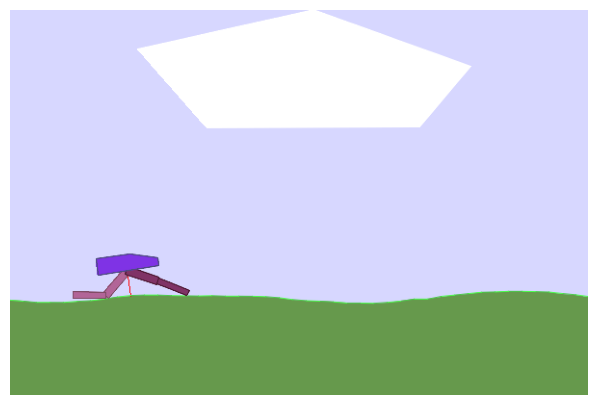

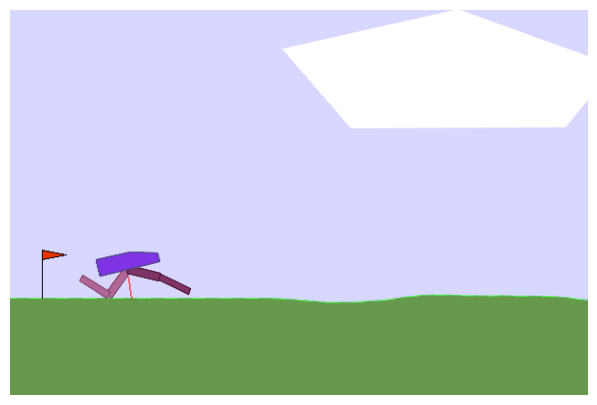

In [11]:
# --- Record & save ----------------------------------------------------------
frames_ppo  = _record(ppo_policy, seed=123)
save_video(frames_ppo, "ppo_best.mp4")

frames_grpo = _record(grpo_policy, seed=123)
save_video(frames_grpo, "grpo_best.mp4")

# --- Inline preview (comment out on headless servers) ----------------------
show_video(frames_ppo)
show_video(frames_grpo)

Training PPO with best hyperparameters and saving history...


/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


Training GRPO with best hyperparameters and saving history...
✅ Saved learning curve plot to 'learning_curves.png'


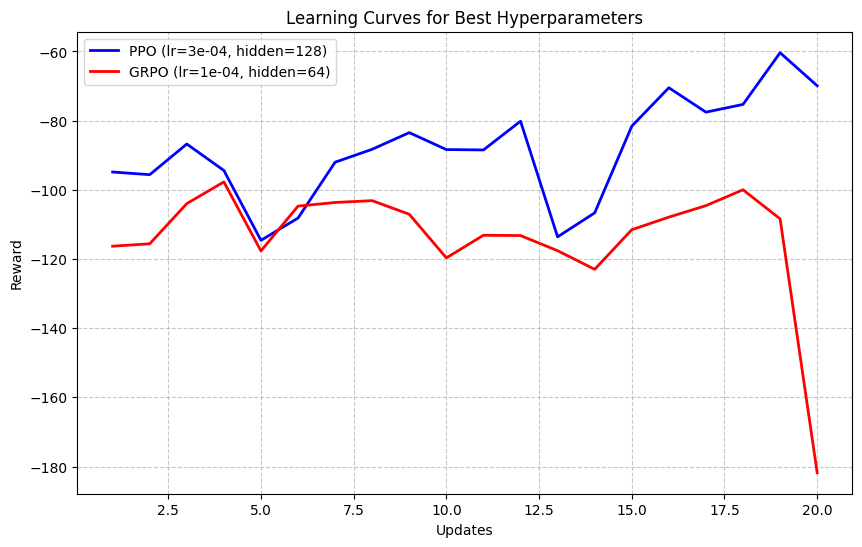


PPO Performance:
  • Final reward: -69.9
  • Best reward: -60.4 (update 19)
  • Average of last 5 updates: -70.7

GRPO Performance:
  • Final reward: -181.8
  • Best reward: -97.7 (update 4)
  • Average of last 5 updates: -120.5


In [12]:
# ══════════════════ 7. Plotting Learning Curves ════════════════════════════
def plot_learning_curves():
    # Re-run the best configurations and save full history
    print("Training PPO with best hyperparameters and saving history...")
    _, ppo_history = train_ppo(
        num_updates=20,  # Increase updates for better curve
        min_steps_per_batch=2000,
        lr=BEST_PPO.lr,
        hidden=int(BEST_PPO.hidden),
        return_policy=True
    )

    print("Training GRPO with best hyperparameters and saving history...")
    _, grpo_history = train_grpo(
        num_updates=20,  # Increase updates for better curve
        group=6,
        lr=BEST_GRP.lr,
        hidden=int(BEST_GRP.hidden),
        return_policy=True
    )

    # Plot the learning curves
    plt.figure(figsize=(10, 6))

    # Create x-axis for updates
    ppo_updates = range(1, len(ppo_history) + 1)
    grpo_updates = range(1, len(grpo_history) + 1)

    # Plot PPO history
    plt.plot(ppo_updates, ppo_history, 'b-', linewidth=2, label=f'PPO (lr={BEST_PPO.lr:.0e}, hidden={int(BEST_PPO.hidden)})')

    # Plot GRPO history
    plt.plot(grpo_updates, grpo_history, 'r-', linewidth=2, label=f'GRPO (lr={BEST_GRP.lr:.0e}, hidden={int(BEST_GRP.hidden)})')

    # Add labels and legend
    plt.xlabel('Updates')
    plt.ylabel('Reward')
    plt.title('Learning Curves for Best Hyperparameters')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Save the figure
    plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
    print("✅ Saved learning curve plot to 'learning_curves.png'")

    # Display the figure
    plt.show()

    return ppo_history, grpo_history

# Call the function to generate the plot
ppo_history, grpo_history = plot_learning_curves()

# Print some statistics about final performance
print("\nPPO Performance:")
print(f"  • Final reward: {ppo_history[-1]:.1f}")
print(f"  • Best reward: {max(ppo_history):.1f} (update {np.argmax(ppo_history)+1})")
print(f"  • Average of last 5 updates: {np.mean(ppo_history[-5:]):.1f}")

print("\nGRPO Performance:")
print(f"  • Final reward: {grpo_history[-1]:.1f}")
print(f"  • Best reward: {max(grpo_history):.1f} (update {np.argmax(grpo_history)+1})")
print(f"  • Average of last 5 updates: {np.mean(grpo_history[-5:]):.1f}")